# Análise de Evasão Escolar

## Contexto:
Análise de um dataset com 150 registros de estudantes, com informações socioeconômicas e acadêmicas. Com o objetivo de identificar fatores associados à evasão escolar.

## Perguntas a serem respondidas neste notebook:

- Existe uma faixa etária predominante entre os evadidos?
- Estudantes que trabalham têm maior probabilidade de evadir?
- A renda influencia na evasão?
- Qual período do curso tem maior taxa de evasão?
- Qual o maior motivo de evasão?
- O desempenho tem alguma relação com a evasão?

## 1. Carregando e explorando os dados:
Importando dados, visualizando formato e informações do dataframe, e apresentando primeiros registros. 

In [41]:
import pandas as pd

df = pd.read_excel('base_aed_evasao_com_estado_civil.xlsx')

In [42]:
print(df.shape)
print()
print(df.info())
print()
df.head()

(150, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Idade                   150 non-null    int64  
 1   Gênero                  150 non-null    object 
 2   Estado Civil            150 non-null    object 
 3   Renda Familiar (R$)     150 non-null    float64
 4   Escola Ensino Médio     150 non-null    object 
 5   Status                  150 non-null    object 
 6   Motivo da Evasão        54 non-null     object 
 7   Trabalha Atualmente     150 non-null    object 
 8   Último Período Cursado  150 non-null    int64  
 9   Desempenho              150 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 11.8+ KB
None



,Idade,Gênero,Estado Civil,Renda Familiar (R$),Escola Ensino Médio,Status,Motivo da Evasão,Trabalha Atualmente,Último Período Cursado,Desempenho
0,18,Feminino,Solteiro(a),1414.37,Pública,Ativo,NaN,Não,5,68.5
1,20,Masculino,Divorciado(a),4238.37,Privada,Evadido,Dificuldade financeira,Não,6,76.4
2,18,Masculino,Viúvo(a),2295.80,Pública,Ativo,NaN,Não,9,77.8
3,27,Outro,Solteiro(a),3765.94,Pública,Evadido,Baixo desempenho,Sim,1,61.9
4,30,Masculino,Casado(a),3991.39,Privada,Ativo,NaN,Sim,1,61.6


Este dataframe já está com os dados limpos e organizados. Deste modo, vamos seguir para a análise exploratória.

## 2. Análise exploratória:

### 2.1 Existe uma faixa etária predominante entre os evadidos?

Calculamos média, moda, mediana e variância da idade dos evadidos,
e visualizamos a distribuição por faixa etária.

Média: 24.11
Moda: 20
Mediana: 24.0


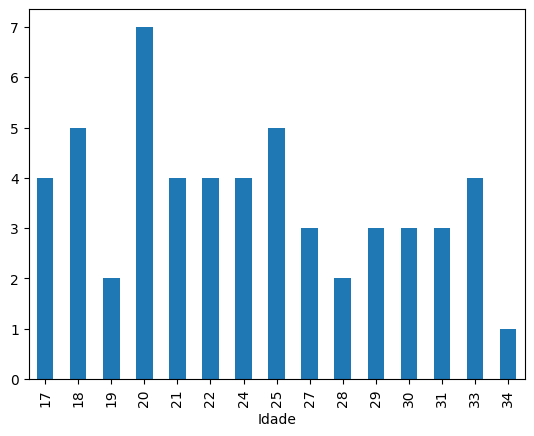

In [43]:
df_evasao_por_idade = df[df['Status'] == 'Evadido'].groupby('Idade').size()

idades_evadidas = df[df['Status'] == 'Evadido']['Idade']

print(f'Média: {idades_evadidas.mean():.2f}')
print(f'Moda: {idades_evadidas.mode()[0]}')
print(f'Mediana: {idades_evadidas.median()}')

plot1 = df_evasao_por_idade.plot(kind = 'bar')
plot1;

Com base na análise visual do gráfico, notamos que as idades com maior número de evasão são: 18, 20 e 25 anos, sendo a média de 24 anos, e a moda de 20.

### 2.2 Estudantes que trabalham têm maior probabilidade de evadir?

Vamos calcular a correlação entre os estudantes que trabalham e que evadiram. Além disso, visualizar a quantidade de alunos que trabalham e que não trabalham, e então calcular a taxa de alunos que trabalham ou não trabalham por status (Ativo, Evadido ou Formado).

Correlação: -0.11

Quantidade de alunos:

Status               Evadido
Trabalha Atualmente         
Não                       31
Sim                       23

Taxa de alunos por status:

Status               Ativo  Evadido  Formado
Trabalha Atualmente                         
Não                  42.67    41.33    16.00
Sim                  44.00    30.67    25.33


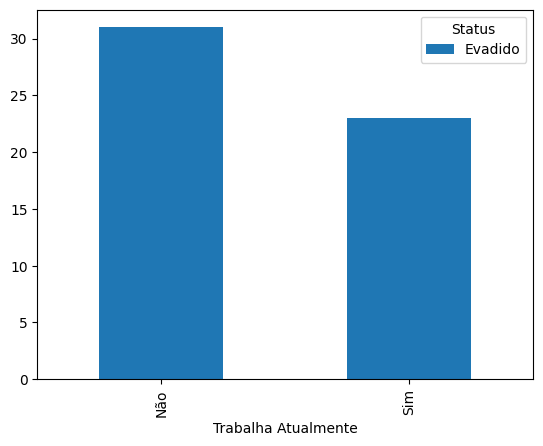

In [44]:
df['Trabalha_Num'] = (df['Trabalha Atualmente'] == 'Sim').astype(int)
df['Evadido_Num'] = (df['Status'] == 'Evadido').astype(int)

correlacao = df['Trabalha_Num'].corr(df['Evadido_Num'])
print(f'Correlação: {correlacao:.2f}\n')

print('Quantidade de alunos:')
print()
df_evadidos = df[df['Status'] == 'Evadido']
tabela_cruzada = pd.crosstab(df_evadidos['Trabalha Atualmente'], df_evadidos['Status'])
print(tabela_cruzada)


print()
print('Taxa de alunos por status:')
print()
percentuais = pd.crosstab(df['Trabalha Atualmente'], df['Status'], normalize='index') * 100
print(percentuais.round(2))


tabela_cruzada.plot(kind = 'bar');

Existe uma correlação negativa fraca entre os estudantes que trabalham e que evadiram, indicando que trabalhar está levemente associado a NÃO evadir.

### 2.3 A renda influencia na evasão?

Calculamos a média, mediana e moda da renda dos estudantes que evadiram e que não evadiram. A partir disso visualizamos as diferenças e a correlação.

In [45]:
renda_media = df.groupby('Status')['Renda Familiar (R$)'].mean().round(2)
renda_media
df['Evadido'] = (df['Status'] == 'Evadido').astype(int)


evadidos = df[df['Status'] == 'Evadido']['Renda Familiar (R$)']

print('\nRenda Evadidos:')
print(f"Média:    R$ {evadidos.mean():.2f}")
print(f"Mediana:  R$ {evadidos.median():.2f}")
print(f"Moda:     R$ {evadidos.mode()[0]:.2f}" if len(evadidos.mode()) > 0 else "Moda: Sem repetição")


nao_evadidos = df[df['Status'] != 'Evadido']['Renda Familiar (R$)']

print("\nRenda Não Evadidos:")
print(f"Média:    R$ {nao_evadidos.mean():.2f}")
print(f"Mediana:  R$ {nao_evadidos.median():.2f}")
print(f"Moda:     R$ {nao_evadidos.mode()[0]:.2f}" if len(nao_evadidos.mode()) > 0 else "Moda: Sem repetição")

print("\nDIFERENÇAS")
print(f"Diferença de Média:   R$ {evadidos.mean() - nao_evadidos.mean():.2f}")
print(f"Diferença de Mediana: R$ {evadidos.median() - nao_evadidos.median():.2f}")

print("\nDESVIO PADRÃO")
print(f"Evadidos:      R$ {evadidos.std():.2f}")
print(f"Não Evadidos:  R$ {nao_evadidos.std():.2f}")

correlacao = df['Renda Familiar (R$)'].corr(df['Evadido'])

print(f"\nCorrelação: {correlacao.__round__(2)}")


Renda Evadidos:
Média:    R$ 2488.89
Mediana:  R$ 2445.96
Moda:     R$ 846.30

Renda Não Evadidos:
Média:    R$ 2605.71
Mediana:  R$ 2495.44
Moda:     R$ 500.00

DIFERENÇAS
Diferença de Média:   R$ -116.82
Diferença de Mediana: R$ -49.48

DESVIO PADRÃO
Evadidos:      R$ 970.65
Não Evadidos:  R$ 1047.85

Correlação: -0.06


A renda não influencia na evasão, tendo em vista que há uma correlação negativa muito fraca.

### 2.4 Qual período do curso tem maior taxa de evasão?

Com base na quantidade de vezes em que um número de último período cursado aparece no dataframe, calculamos e verificamos qual representa a maior taxa entre os evadidos.

In [46]:
tabela_periodo = pd.crosstab(df['Último Período Cursado'], df['Status'], normalize = 'index') * 100

periodo_maior = tabela_periodo['Evadido'].idxmax()
taxa_periodo_maior = tabela_periodo['Evadido'].max()


print(tabela_periodo.round(2))

print(f'\nO período com maior taxa de evasão é o {periodo_maior}, com {taxa_periodo_maior:.2f}%')

Status                  Ativo  Evadido  Formado
Último Período Cursado                         
1                       44.44    27.78    27.78
2                       41.18    23.53    35.29
3                       77.78     0.00    22.22
4                       41.18    35.29    23.53
5                       28.57    71.43     0.00
6                       52.63    47.37     0.00
7                       46.15    38.46    15.38
8                       53.33    40.00     6.67
9                       29.17    33.33    37.50
10                      27.27    54.55    18.18

O período com maior taxa de evasão é o 5, com 71.43%


Notamos que o período com maior taxa de evasão é o 5.

### 2.5 Qual o maior motivo de evasão?

Listamos os motivos de evasão em ordem decrescente com base na quantidade de vezes que eles aparecem no DF.

In [47]:
motivo_evasao = df[df['Status'] == 'Evadido']['Motivo da Evasão'].value_counts()
motivo_evasao

Motivo da Evasão
Baixo desempenho          18
Trabalho                  11
Dificuldade financeira    10
Motivos pessoais           8
Mudança de curso           7
Name: count, dtype: int64

O maior motivo de evasão está relacionado ao baixo desempenho do estudante.

### 2.6 O desempenho tem alguma relação com a evasão?

Assim como na análise 2.3, calcuamos a média, mediana e moda, mas desta vez do desempenho dos estudantes que evariam e que não evadiram. A partir disso visualzamos as diferenças e a correlação.

In [48]:
desempenho_evasao = df[['Status', 'Desempenho']]

evadidos = df[df['Status'] == 'Evadido']['Desempenho']

print('\nDesempenho Evadidos:')
print(f"Média:     {evadidos.mean():.2f}")
print(f"Mediana:   {evadidos.median():.2f}")
print(f"Moda:      {evadidos.mode()[0]:.2f}" if len(evadidos.mode()) > 0 else "Moda: Sem repetição")


nao_evadidos = df[df['Status'] != 'Evadido']['Desempenho']

print("\nDesempenho Não Evadidos:")
print(f"Média:     {nao_evadidos.mean():.2f}")
print(f"Mediana:   {nao_evadidos.median():.2f}")
print(f"Moda:      {nao_evadidos.mode()[0]:.2f}" if len(nao_evadidos.mode()) > 0 else "Moda: Sem repetição")

print("\nDIFERENÇAS")
print(f"Diferença de Média:    {evadidos.mean() - nao_evadidos.mean():.2f}")
print(f"Diferença de Mediana:  {evadidos.median() - nao_evadidos.median():.2f}")

correlacao = df['Desempenho'].corr(df['Evadido'])

print(f"\nCorrelação: {correlacao.__round__(2)}")


Desempenho Evadidos:
Média:     74.02
Mediana:   73.20
Moda:      72.40

Desempenho Não Evadidos:
Média:     71.71
Mediana:   70.65
Moda:      61.70

DIFERENÇAS
Diferença de Média:    2.31
Diferença de Mediana:  2.55

Correlação: 0.15


A correlação positiva de 0.15 indica que, neste dataset, alunos com desempenho objetivamente maior apresentam leve tendência a evadir mais. Esse resultado aparentemente contrasta com o principal motivo de evasão relatado na seção 2.5 (baixo desempenho), sugerindo uma diferença entre a percepção subjetiva do aluno e sua nota real — um ponto que mereceria investigação mais aprofundada com dados adicionais.

## Conclusão


- As idades com maior número de evasão são: 18, 20 e 25 anos, com moda de 20 anos e média de 24 anos.

- Trabalhar está levemente associado a NÃO evadir - pois a correlação entre emprego e evasão é negativa e próxima de 0.

- A renda não é um fator que isoladamente determina a evasão.

- O 5° período concentra a maior taxa de evasão.

- O motivo de evasão mais frequente informado pelos estudantes está relacionado ao baixo desempenho.

- A correlação objetiva entre desempenho e evasão é positiva (0.15), indicando que a percepção do aluno sobre seu desempenho (conforme item anterior - seção 2.5) pode ser diferente da métrica objetiva registrada — se tornando um ponto que merece investigação adicional.